# MoCA Score Prediction Model

## 1. Import Required Libraries

Import all necessary libraries for data processing, machine learning, and visualization.

In [33]:

import os, time, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from scipy.optimize import nnls
from sklearn.model_selection import LeaveOneOut, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures, QuantileTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import BayesianRidge, RidgeCV
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
import joblib
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

print("All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")


All libraries imported successfully!
Pandas version: 3.0.1
Scikit-learn version: 1.8.0


## 2. Load and Prepare Data

Load the MoCA classifications and enhanced features datasets, then merge them for analysis.

In [34]:

def load_and_prepare_data():
    """Load and merge the datasets"""
    print("Loading datasets...")
    
    # Load the datasets from Model A (single source of truth)
    labels_df = pd.read_csv('../Model A - All Data/3.3 moca_classifications.csv')
    features_df = pd.read_csv('../Model A - All Data/4. enhanced_features.csv')
    
    print(f"Labels shape: {labels_df.shape}")
    print(f"Features shape: {features_df.shape}")
    
    # Harmonize Subject ID column names
    if 'Subject_ID' in features_df.columns and 'SubjectID' not in features_df.columns:
        features_df = features_df.rename(columns={'Subject_ID': 'SubjectID'})
    if 'Subject_ID' in labels_df.columns and 'SubjectID' not in labels_df.columns:
        labels_df = labels_df.rename(columns={'Subject_ID': 'SubjectID'})
    
    # Merge datasets on SubjectID
    data = pd.merge(features_df, labels_df, on='SubjectID')
    print(f"Merged data shape: {data.shape}")
    
    return data

# Load the data
data = load_and_prepare_data()

# Display basic information
print("\nDataset Overview:")
print(f"Number of subjects: {len(data)}")
print(f"Number of features: {data.shape[1] - 3}")
print(f"MoCA score range: {data['MoCA'].min()} - {data['MoCA'].max()}")
print(f"Mean MoCA score: {data['MoCA'].mean():.2f}")

# Display first few rows
print("\nFirst 5 rows:")
data.head()


Loading datasets...
Labels shape: (81, 18)
Features shape: (81, 78)
Merged data shape: (81, 95)

Dataset Overview:
Number of subjects: 81
Number of features: 92
MoCA score range: 11 - 30
Mean MoCA score: 24.96

First 5 rows:


,SubjectID,mean_velocity,std_velocity,foot_distance_std,knee_angles_mean,core_mean_velocity,z_range,x_mean,mean_confidence,com_autocorr_1,...,Height,Number of falls in the past one month,Activity level,FRT,TUG,FTSTS,Handgrip R,Handgrip L,MoCA,Classification
0,E01,1.086273,1.519558,0.025353,132.343082,0.425204,0.949234,0.484756,0.962932,0.985003,...,147.0,0,Moderately active,19.5,11.71,9.17,16.933333,14.666667,26,Healthy
1,E02,1.080307,1.347848,0.027418,127.890007,0.407819,0.857571,0.497563,0.967915,0.978642,...,153.0,0,Moderately active,32.8,13.31,15.25,20.100000,17.533333,17,Moderate
2,E03,1.000293,1.431096,0.020029,119.635536,0.410353,0.741380,0.469585,0.965980,0.968261,...,150.0,0,Moderately active,17.5,7.64,8.91,17.560000,16.560000,22,Mild
3,E04,0.804184,1.135019,0.027457,111.946627,0.336347,0.699017,0.466782,0.956619,0.981221,...,136.0,0,Lightly Active,20.2,10.39,15.21,14.600000,11.500000,21,Mild
4,E05,0.912706,1.257029,0.020693,128.851724,0.405694,0.781477,0.486613,0.971332,0.973570,...,NaN,0,Moderately active,24.0,12.99,14.56,17.200000,13.960000,22,Mild


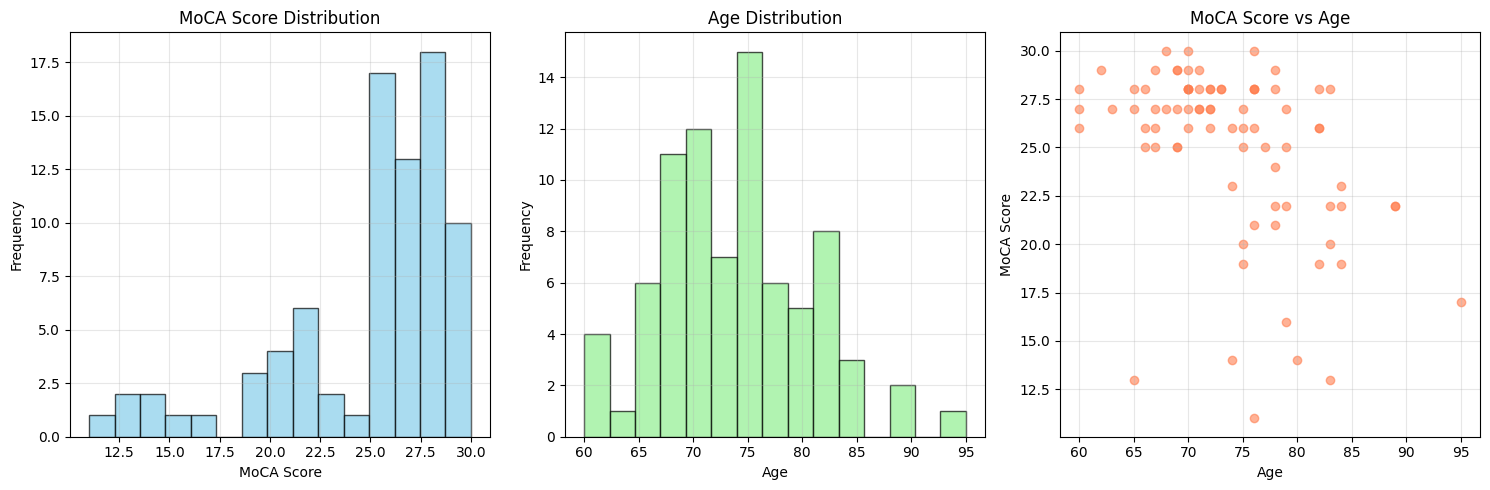


MoCA Score Statistics:
count    81.000000
mean     24.962963
std       4.380195
min      11.000000
25%      23.000000
50%      27.000000
75%      28.000000
max      30.000000
Name: MoCA, dtype: float64


In [35]:
# Explore the data distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# MoCA score distribution
axes[0].hist(data['MoCA'], bins=15, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].set_title('MoCA Score Distribution')
axes[0].set_xlabel('MoCA Score')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Age distribution
axes[1].hist(data['Age'], bins=15, alpha=0.7, color='lightgreen', edgecolor='black')
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

# MoCA vs Age scatter plot
axes[2].scatter(data['Age'], data['MoCA'], alpha=0.6, color='coral')
axes[2].set_title('MoCA Score vs Age')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('MoCA Score')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Basic statistics
print("\nMoCA Score Statistics:")
print(data['MoCA'].describe())

## 3. Data Preprocessing and Feature Engineering

Implement comprehensive preprocessing including advanced feature engineering, data augmentation, and categorical encoding.

In [36]:

# (Feature engineering is handled by the engineer() function in the preprocessing cell above.)
print("Feature engineering: see engineer() in preprocessing cell.")


Feature engineering: see engineer() in preprocessing cell.


In [37]:

# (Mixup augmentation is handled by augment_tail() inside each LOOCV fold — see run_loocv().)
print("Augmentation: see augment_tail() in the LOOCV helper cells.")


Augmentation: see augment_tail() in the LOOCV helper cells.


In [38]:

# Model B: exclude physical performance tests, keep dance + cognitive features only
PHYS_EXCLUDE = ['TUG', 'FRT', 'FTSTS', 'Handgrip R', 'Handgrip L']
EXCLUDE_COLS  = ['SubjectID', 'MoCA', 'Classification'] + PHYS_EXCLUDE

feat_cols = [c for c in data.columns if c not in EXCLUDE_COLS]
X_raw     = data[feat_cols].copy()
y         = data['MoCA'].copy()

# Encode categoricals
for col in X_raw.select_dtypes(include=['object']).columns:
    X_raw[col] = LabelEncoder().fit_transform(X_raw[col].astype(str))
X_raw = X_raw.fillna(X_raw.median())
X_raw = X_raw.drop(columns=X_raw.columns[X_raw.var() == 0])

def engineer(X):
    """Dance-focused feature engineering (replaces physical tests with dance composites)."""
    Xe = X.copy()

    if 'Education level' in X.columns and 'Age' in X.columns:
        Xe['cog_reserve_idx'] = X['Education level'] / (X['Age'] / 70 + 1e-8)
        Xe['edu_age']         = X['Education level'] * X['Age']

    demo = [c for c in ['Age', 'Education level'] if c in X.columns]
    if len(demo) >= 2:
        from sklearn.preprocessing import PolynomialFeatures as PF
        pf = PF(degree=2, interaction_only=True, include_bias=False).fit_transform(X[demo])
        for i in range(pf.shape[1] - len(demo)):
            Xe[f'demo_poly_{i}'] = pf[:, len(demo) + i]

    bal   = [c for c in X.columns if 'sway'  in c.lower() or 'cop'   in c.lower()]
    coord = [c for c in X.columns if 'coord' in c.lower() or 'coupl' in c.lower()]
    vel   = [c for c in X.columns if 'veloc' in c.lower() or 'speed' in c.lower()]
    spec  = [c for c in X.columns if 'spect' in c.lower() or 'freq'  in c.lower()]
    stab  = [c for c in X.columns if 'stab'  in c.lower() or 'regul' in c.lower()]
    asym  = [c for c in X.columns if 'asym'  in c.lower() or 'diff'  in c.lower()]

    if bal:
        Xe['bal_mean']  = X[bal].mean(axis=1)
        Xe['bal_std']   = X[bal].std(axis=1)
        Xe['bal_range'] = X[bal].max(axis=1) - X[bal].min(axis=1)
    if coord:
        Xe['coord_mean'] = X[coord].mean(axis=1)
        Xe['coord_std']  = X[coord].std(axis=1)
    if vel:
        vmean = X[vel].mean(axis=1); vstd = X[vel].std(axis=1)
        Xe['vel_mean'] = vmean
        Xe['vel_cv']   = vstd / (vmean.abs() + 1e-8)
    if spec:
        Xe['spec_mean'] = X[spec].mean(axis=1)
    if stab:
        Xe['stab_mean'] = X[stab].mean(axis=1)
    if asym:
        Xe['asym_mean'] = X[asym].mean(axis=1)

    if coord and vel:
        Xe['coord_vel']        = Xe.get('coord_mean', 0) * Xe.get('vel_mean', 0)
        Xe['motor_complexity'] = Xe.get('vel_cv', 0) * Xe.get('coord_std', 0)
    if bal and coord:
        Xe['coord_bal_ratio']     = Xe.get('coord_mean', 0) / (Xe.get('bal_mean', 1) + 1e-8)
        Xe['bal_coord_composite'] = Xe.get('bal_mean', 0) + Xe.get('coord_mean', 0)
    if vel and 'Age' in X.columns:
        Xe['age_vel_cv']   = X['Age'] * Xe.get('vel_cv', 0)
        Xe['age_vel_mean'] = X['Age'] * Xe.get('vel_mean', 0)
    if coord and 'Education level' in X.columns:
        Xe['edu_coord'] = X['Education level'] * Xe.get('coord_mean', 0)
    if vel and 'Education level' in X.columns:
        Xe['edu_vel_cv'] = X['Education level'] * Xe.get('vel_cv', 0)
    if bal and vel:
        Xe['bal_vel_ratio'] = Xe.get('bal_mean', 0) / (Xe.get('vel_mean', 1) + 1e-8)
    if spec and stab:
        Xe['spec_stab'] = Xe.get('spec_mean', 0) * Xe.get('stab_mean', 0)
    if asym and vel:
        Xe['asym_vel'] = Xe.get('asym_mean', 0) * Xe.get('vel_mean', 0)
    return Xe

X_eng = engineer(X_raw)
print(f"Feature engineering: {X_raw.shape[1]} raw → {X_eng.shape[1]} engineered features")
print(f"Subjects: {len(y)} | MoCA {y.min():.0f}–{y.max():.0f}  mean={y.mean():.1f}  std={y.std():.1f}")


Feature engineering: 86 raw → 110 engineered features
Subjects: 81 | MoCA 11–30  mean=25.0  std=4.4


## 4. Feature Selection

Implement advanced feature selection using multiple methods to identify the most predictive features.

In [39]:

def select_features(X_tr, y_tr, n=30):
    """Feature selection inside each LOOCV fold — no leakage."""
    corr  = X_tr.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop  = [c for c in upper.columns if any(upper[c] > 0.95)]
    Xr    = X_tr.drop(columns=drop)

    k    = min(n * 2, Xr.shape[1])
    mi   = mutual_info_regression(Xr, y_tr, random_state=42)
    mi_f = Xr.columns[np.argsort(mi)[-k:]].tolist()
    fk   = SelectKBest(f_regression, k=k).fit(Xr, y_tr)
    fs_f = Xr.columns[fk.get_support()].tolist()

    comb = list(set(mi_f + fs_f))
    if len(comb) > n:
        idx  = SelectKBest(f_regression, k=n).fit(Xr[comb], y_tr).get_support(indices=True)
        comb = [comb[i] for i in idx]
    return Xr[comb], comb


def augment_tail(X, y, n_mix=50, alpha=0.4, seed=42):
    """Tail-focused Mixup augmentation (applied only to training fold)."""
    rng = np.random.RandomState(seed)
    med = np.median(y.values)
    w   = np.abs(y.values - med) + 0.5
    w  /= w.sum()

    augX, augY = [], []
    for _ in range(n_mix):
        i, j = rng.choice(len(X), size=2, p=w)
        lam  = rng.beta(alpha, alpha)
        augX.append(lam * X.values[i] + (1 - lam) * X.values[j])
        augY.append(lam * y.values[i]  + (1 - lam) * y.values[j])

    Xa = pd.DataFrame(
        np.vstack([X.values] + [a.reshape(1, -1) for a in augX]),
        columns=X.columns)
    ya = pd.Series(np.concatenate([y.values, augY]))
    return Xa, ya

print("LOOCV-safe feature selection and Mixup augmentation helpers defined.")


LOOCV-safe feature selection and Mixup augmentation helpers defined.


In [40]:

def run_loocv(X_all, y_all, make_model, n_feat=30,
              do_aug=True, use_qt=False, label=''):
    """LOOCV engine: fits model once per left-out subject."""
    loo   = LeaveOneOut()
    preds = np.zeros(len(y_all))
    t0    = time.time()

    for tr_idx, te_idx in loo.split(X_all):
        Xtr = X_all.iloc[tr_idx].copy()
        Xte = X_all.iloc[te_idx].copy()
        ytr = y_all.iloc[tr_idx].copy()

        Xtr_sel, feats = select_features(Xtr, ytr, n=n_feat)
        Xte_sel        = Xte[feats]
        Xtr_orig       = Xtr_sel.copy()

        if do_aug:
            Xtr_sel, ytr = augment_tail(Xtr_sel, ytr, n_mix=50, alpha=0.4)

        if use_qt:
            qt = QuantileTransformer(output_distribution='normal',
                                     n_quantiles=min(80, len(Xtr_orig)),
                                     random_state=42)
            qt.fit(Xtr_orig)
            Xtr_sc = qt.transform(Xtr_sel)
            Xte_sc = qt.transform(Xte_sel)
        else:
            sc = StandardScaler()
            Xtr_sc = sc.fit_transform(Xtr_sel)
            Xte_sc = sc.transform(Xte_sel)

        m = make_model()
        m.fit(Xtr_sc, ytr)
        preds[te_idx] = m.predict(Xte_sc)

    r2  = r2_score(y_all, preds)
    mae = mean_absolute_error(y_all, preds)
    a3  = (np.abs(y_all.values - preds) <= 3).mean()
    t   = time.time() - t0
    print(f"  {label:<42}: R²={r2:+.4f}  MAE={mae:.3f}  ±3pt={a3*100:.1f}%  ({t:.0f}s)")
    return preds, {'r2': r2, 'mae': mae,
                   'a1': (np.abs(y_all.values - preds) <= 1).mean(),
                   'a2': (np.abs(y_all.values - preds) <= 2).mean(),
                   'a3': a3}

print("LOOCV engine defined.")


LOOCV engine defined.


## 5. Model Training and Evaluation

Train multiple optimized models and select the best performer based on comprehensive evaluation metrics.

In [41]:

# Model definitions (nested RandomizedSearchCV with no augmentation, same as run_push_r2_b.py)
N_ITER, N_CV = 12, 3

SVR_RBF_SPACE = {
    'C':       [0.5, 1, 5, 10, 50, 100, 200, 500, 1000],
    'gamma':   [0.001, 0.005, 0.01, 0.05, 0.1, 'scale'],
    'epsilon': [0.05, 0.1, 0.2, 0.5],
}
SVR_POLY_SPACE = {
    'C':      [0.5, 1, 5, 10, 50, 100],
    'degree': [2, 3],
    'gamma':  [0.01, 0.1, 'scale'],
    'coef0':  [0.0, 0.5, 1.0],
}
GBM_SPACE = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [1, 2, 3],
    'learning_rate':    [0.01, 0.03, 0.05, 0.1, 0.15],
    'min_samples_leaf': [2, 3, 5],
    'subsample':        [0.7, 0.8, 1.0],
    'max_features':     ['sqrt', 0.8, 1.0],
}
RF_SPACE = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [4, 6, 8, None],
    'min_samples_leaf': [2, 3, 4],
    'max_features':     ['sqrt', 0.5, 0.7],
}
ET_SPACE = {
    'n_estimators':     [100, 200],
    'max_depth':        [4, 6, 8, None],
    'min_samples_leaf': [2, 3, 5],
    'max_features':     ['sqrt', 0.5, 0.8],
}

def _rscv(estimator, space, n_iter=N_ITER):
    return RandomizedSearchCV(estimator, space, n_iter=n_iter, cv=N_CV,
                              scoring='r2', n_jobs=-1, random_state=42)

# (label, factory, do_aug, use_qt)  — augmentation disabled for No-Aug run
MODELS = [
    ('SVR-RBF  [nested CV + QT]',
     lambda: _rscv(SVR(kernel='rbf'),  SVR_RBF_SPACE),  False, True),
    ('SVR-Poly [nested CV + QT]',
     lambda: _rscv(SVR(kernel='poly'), SVR_POLY_SPACE), False, True),
    ('GBM      [nested CV]',
     lambda: _rscv(GradientBoostingRegressor(random_state=42), GBM_SPACE), False, False),
    ('RF       [nested CV]',
     lambda: _rscv(RandomForestRegressor(random_state=42, n_jobs=1), RF_SPACE, n_iter=10),
     False, False),
    ('Extra Trees [nested CV]',
     lambda: _rscv(ExtraTreesRegressor(random_state=42, n_jobs=1), ET_SPACE, n_iter=10),
     False, False),
    ('Ridge-CV [QT]',
     lambda: RidgeCV(alphas=np.logspace(-3, 3, 50)),   False, True),
    ('Bayesian Ridge [QT]',
     lambda: BayesianRidge(),                            False, True),
    ('GPR Matern 3/2 [QT]',
     lambda: GaussianProcessRegressor(
         kernel=C(1.0, (1e-3, 1e3)) * Matern(nu=1.5) + WhiteKernel(0.5),
         n_restarts_optimizer=5, normalize_y=True, random_state=42),
     False, True),
]

print(f"Model definitions ready — {len(MODELS)} models to run under LOOCV n={len(y)}.")


Model definitions ready — 8 models to run under LOOCV n=81.


In [42]:

print(f"\nLOOCV n={len(y)} | Nested CV (n_iter={N_ITER}, cv={N_CV}) | "
      f"No augmentation | 30 features  [Model B: dance+cog only]")
print("─" * 74)

all_preds   = {}
all_metrics = {}
for label, factory, do_aug, use_qt in MODELS:
    p, m = run_loocv(X_eng, y, factory, n_feat=30,
                     do_aug=do_aug, use_qt=use_qt, label=label)
    all_preds[label]   = p
    all_metrics[label] = m

# ── NNLS ensemble ────────────────────────────────────────────────────────────
pos_keys = sorted([k for k, v in all_metrics.items() if v['r2'] > 0.0],
                  key=lambda k: all_metrics[k]['r2'], reverse=True)

if len(pos_keys) >= 2:
    P = np.column_stack([all_preds[k] for k in pos_keys])
    w, _ = nnls(P, y.values)
    if w.sum() > 0:
        w   /= w.sum()
        ensp = P @ w
        er2  = r2_score(y, ensp)
        emae = mean_absolute_error(y, ensp)
        ea3  = (np.abs(y.values - ensp) <= 3).mean()
        all_metrics['★ NNLS Ensemble'] = {
            'r2': er2, 'mae': emae,
            'a1': (np.abs(y.values - ensp) <= 1).mean(),
            'a2': (np.abs(y.values - ensp) <= 2).mean(),
            'a3': ea3,
        }
        all_preds['★ NNLS Ensemble'] = ensp
        print(f"\n  {'★ NNLS Ensemble':<42}: R²={er2:+.4f}  MAE={emae:.3f}  ±3pt={ea3*100:.1f}%")
        print(f"  NNLS weights: " +
              "  ".join(f"{k.split('[')[0].strip()}={ww:.3f}" for k, ww in zip(pos_keys, w)))



LOOCV n=81 | Nested CV (n_iter=12, cv=3) | No augmentation | 30 features  [Model B: dance+cog only]
──────────────────────────────────────────────────────────────────────────
  SVR-RBF  [nested CV + QT]                 : R²=+0.2086  MAE=2.887  ±3pt=65.4%  (10s)
  SVR-Poly [nested CV + QT]                 : R²=+0.1863  MAE=2.761  ±3pt=66.7%  (7s)
  GBM      [nested CV]                      : R²=+0.3338  MAE=2.663  ±3pt=66.7%  (50s)
  RF       [nested CV]                      : R²=+0.3219  MAE=2.706  ±3pt=61.7%  (73s)
  Extra Trees [nested CV]                   : R²=+0.3873  MAE=2.507  ±3pt=70.4%  (27s)
  Ridge-CV [QT]                             : R²=+0.1869  MAE=3.068  ±3pt=55.6%  (5s)
  Bayesian Ridge [QT]                       : R²=+0.1880  MAE=3.050  ±3pt=54.3%  (4s)
  GPR Matern 3/2 [QT]                       : R²=+0.3359  MAE=2.592  ±3pt=69.1%  (9s)

  ★ NNLS Ensemble                           : R²=+0.3952  MAE=2.482  ±3pt=72.8%
  NNLS weights: Extra Trees=0.734  GPR Matern 3/2=0

In [43]:

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'Model':<44} {'R²':>8} {'MAE':>7} {'±1pt':>7} {'±2pt':>7} {'±3pt':>7}")
print("─" * 80)
for name, m in sorted(all_metrics.items(), key=lambda x: x[1]['r2'], reverse=True):
    print(f"  {name:<42} {m['r2']:>8.4f} {m['mae']:>7.3f} "
          f"{m['a1']*100:>6.1f}% {m['a2']*100:>6.1f}% {m['a3']*100:>6.1f}%")

best_name = max(all_metrics, key=lambda k: all_metrics[k]['r2'])
bm = all_metrics[best_name]
print(f"\nBest model: {best_name}")
print(f"  R²  = {bm['r2']:.4f}  ({bm['r2']*100:.1f}% variance explained)")
print(f"  MAE = {bm['mae']:.4f}")
print(f"  Accuracy ±3 points: {bm['a3']*100:.1f}%")



Model                                              R²     MAE    ±1pt    ±2pt    ±3pt
────────────────────────────────────────────────────────────────────────────────
  ★ NNLS Ensemble                              0.3952   2.482   29.6%   49.4%   72.8%
  Extra Trees [nested CV]                      0.3873   2.507   28.4%   48.1%   70.4%
  GPR Matern 3/2 [QT]                          0.3359   2.592   28.4%   48.1%   69.1%
  GBM      [nested CV]                         0.3338   2.663   23.5%   45.7%   66.7%
  RF       [nested CV]                         0.3219   2.706   27.2%   46.9%   61.7%
  SVR-RBF  [nested CV + QT]                    0.2086   2.887   21.0%   42.0%   65.4%
  Bayesian Ridge [QT]                          0.1880   3.050   16.0%   39.5%   54.3%
  Ridge-CV [QT]                                0.1869   3.068   16.0%   39.5%   55.6%
  SVR-Poly [nested CV + QT]                    0.1863   2.761   32.1%   45.7%   66.7%

Best model: ★ NNLS Ensemble
  R²  = 0.3952  (39.5% varian

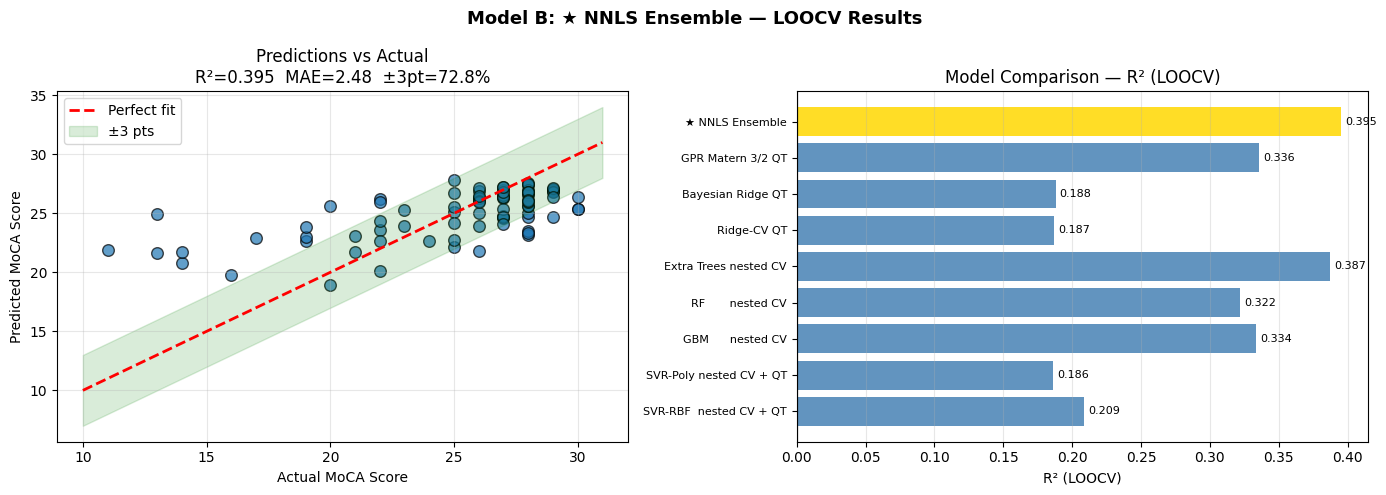

Visualization saved to moca_prediction_results.png


In [44]:

# ── Visualization: LOOCV predictions vs actual for best model ─────────────────
best_pred = all_preds[best_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Model B: {best_name} — LOOCV Results', fontsize=13, fontweight='bold')

# Scatter: predicted vs actual
axes[0].scatter(y.values, best_pred, alpha=0.7, s=70, edgecolors='black')
lo, hi = y.min() - 1, y.max() + 1
axes[0].plot([lo, hi], [lo, hi], 'r--', lw=2, label='Perfect fit')
x_range = np.linspace(lo, hi, 100)
axes[0].fill_between(x_range, x_range - 3, x_range + 3, alpha=0.15, color='green', label='±3 pts')
axes[0].set_xlabel('Actual MoCA Score'); axes[0].set_ylabel('Predicted MoCA Score')
axes[0].set_title(f'Predictions vs Actual\nR²={bm["r2"]:.3f}  MAE={bm["mae"]:.2f}  ±3pt={bm["a3"]*100:.1f}%')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Bar chart: R² for all models
names = list(all_metrics.keys())
r2s   = [all_metrics[n]['r2'] for n in names]
colors = ['gold' if n == best_name else 'steelblue' for n in names]
axes[1].barh(range(len(names)), r2s, color=colors, alpha=0.85)
axes[1].set_yticks(range(len(names)))
axes[1].set_yticklabels([n.replace('[', '').replace(']', '') for n in names], fontsize=8)
axes[1].set_xlabel('R² (LOOCV)')
axes[1].set_title('Model Comparison — R² (LOOCV)')
axes[1].axvline(0, color='black', lw=0.8)
for i, v in enumerate(r2s):
    axes[1].text(max(v + 0.003, 0.005), i, f'{v:.3f}', va='center', fontsize=8)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('moca_prediction_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved to moca_prediction_results.png")


In [45]:

print("\n" + "="*80)
print("FINAL RESULTS  (No Augmentation, LOOCV n=81)  — Model B: Dance + Cognitive Only")
print("="*80)
print(f"\n{'Model':<44} {'R²':>8} {'MAE':>7} {'±3pts':>8}")
print("-" * 72)
for name, m in sorted(all_metrics.items(), key=lambda x: x[1]['r2'], reverse=True):
    star = "★ " if name == best_name else "  "
    print(f"  {star}{name:<42} {m['r2']*100:>7.1f}% {m['mae']:>7.2f} {m['a3']*100:>7.1f}%")

print(f"\n{'─'*72}")
print(f"Best model : {best_name}")
print(f"R²         : {bm['r2']:.4f}  ({bm['r2']*100:.1f}% variance explained)")
print(f"MAE        : {bm['mae']:.4f} points")
print(f"Accuracy ±3 points: {bm['a3']*100:.1f}%")



FINAL RESULTS  (No Augmentation, LOOCV n=81)  — Model B: Dance + Cognitive Only

Model                                              R²     MAE    ±3pts
------------------------------------------------------------------------
  ★ ★ NNLS Ensemble                               39.5%    2.48    72.8%
    Extra Trees [nested CV]                       38.7%    2.51    70.4%
    GPR Matern 3/2 [QT]                           33.6%    2.59    69.1%
    GBM      [nested CV]                          33.4%    2.66    66.7%
    RF       [nested CV]                          32.2%    2.71    61.7%
    SVR-RBF  [nested CV + QT]                     20.9%    2.89    65.4%
    Bayesian Ridge [QT]                           18.8%    3.05    54.3%
    Ridge-CV [QT]                                 18.7%    3.07    55.6%
    SVR-Poly [nested CV + QT]                     18.6%    2.76    66.7%

────────────────────────────────────────────────────────────────────────
Best model : ★ NNLS Ensemble
R²         : 0

## 6. Model Extraction and Testing

Save the trained models, preprocessing components, and create functionality to test the model on new data.

In [46]:

# LOOCV does not produce a single trained model (one model per fold).
# The NNLS ensemble weights below summarise which base learners contributed most.
if '★ NNLS Ensemble' in all_preds:
    pos_keys = sorted([k for k, v in all_metrics.items()
                       if v['r2'] > 0.0 and k != '★ NNLS Ensemble'],
                      key=lambda k: all_metrics[k]['r2'], reverse=True)
    P    = np.column_stack([all_preds[k] for k in pos_keys])
    w, _ = nnls(P, y.values)
    if w.sum() > 0:
        w /= w.sum()
    print("NNLS ensemble weights:")
    for k, ww in zip(pos_keys, w):
        print(f"  {k:<44}  {ww:.4f}")


NNLS ensemble weights:
  Extra Trees [nested CV]                       0.7337
  GPR Matern 3/2 [QT]                           0.2663
  GBM      [nested CV]                          0.0000
  RF       [nested CV]                          0.0000
  SVR-RBF  [nested CV + QT]                     0.0000
  Bayesian Ridge [QT]                           0.0000
  Ridge-CV [QT]                                 0.0000
  SVR-Poly [nested CV + QT]                     0.0000


In [47]:

# Show per-subject LOOCV predictions for the best model
print(f"Per-subject LOOCV predictions — {best_name}")
print(f"{'Subject':<12} {'Actual':>8} {'Predicted':>10} {'Error':>8}")
print("─" * 42)
for subj, actual, pred in zip(data['SubjectID'], y.values, all_preds[best_name]):
    err = actual - pred
    flag = " ◄" if abs(err) > 5 else ""
    print(f"  {subj:<10}  {actual:>8.0f}  {pred:>10.1f}  {err:>+8.1f}{flag}")


Per-subject LOOCV predictions — ★ NNLS Ensemble
Subject        Actual  Predicted    Error
──────────────────────────────────────────
  E01               26        26.9      -0.9
  E02               17        22.9      -5.9 ◄
  E03               22        23.5      -1.5
  E04               21        23.0      -2.0
  E05               22        24.3      -2.3
  E06               28        24.7      +3.3
  E07               29        27.0      +2.0
  E08               28        25.0      +3.0
  E09               24        22.6      +1.4
  E10               27        24.6      +2.4
  E11               28        23.2      +4.8
  E12               29        26.9      +2.1
  E13               26        27.2      -1.2
  E14               23        23.9      -0.9
  E15               16        19.7      -3.7
  E16               11        21.9     -10.9 ◄
  E17               20        18.9      +1.1
  E18               30        25.4      +4.6
  E19               26        23.9      +2.1
  E20   

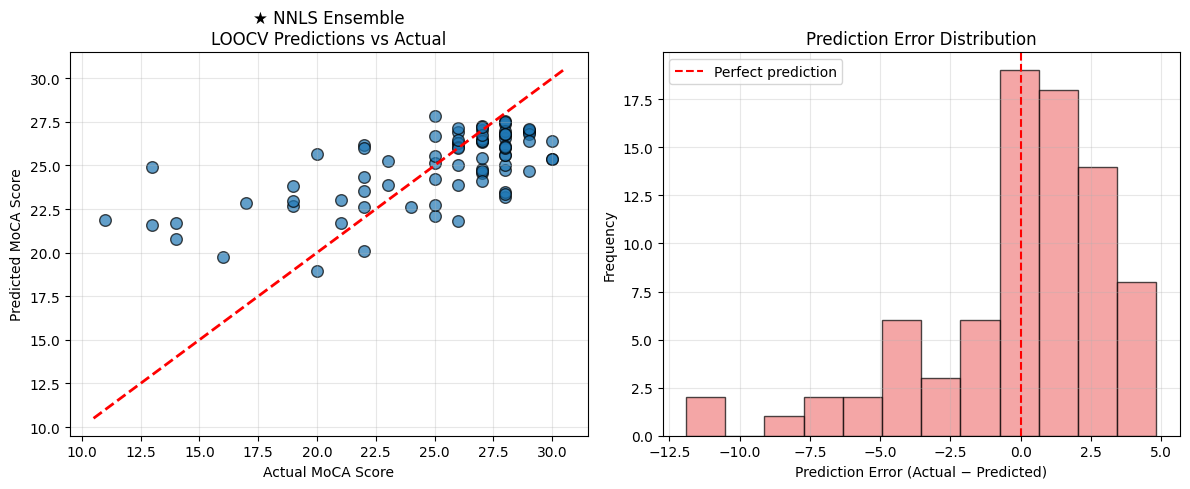

R² = 0.3952 | MAE = 2.4819 | ±3pt = 72.8%


In [48]:

# Best model LOOCV predictions vs actual
best_pred = all_preds[best_name]
errors    = y.values - best_pred

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y.values, best_pred, alpha=0.7, s=70, edgecolors='black')
lims = [y.min() - 0.5, y.max() + 0.5]
plt.plot(lims, lims, 'r--', lw=2)
plt.xlabel('Actual MoCA Score'); plt.ylabel('Predicted MoCA Score')
plt.title(f'{best_name}\nLOOCV Predictions vs Actual'); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(errors, bins=12, alpha=0.7, color='lightcoral', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', label='Perfect prediction')
plt.xlabel('Prediction Error (Actual − Predicted)')
plt.ylabel('Frequency'); plt.title('Prediction Error Distribution')
plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print(f"R² = {bm['r2']:.4f} | MAE = {bm['mae']:.4f} | ±3pt = {bm['a3']*100:.1f}%")


In [49]:

# Quick subject-level lookup: predicted vs actual MoCA for any subject
lookup = dict(zip(data['SubjectID'].tolist(), zip(y.values, all_preds[best_name])))
print("Sample predictions (5 random subjects):")
np.random.seed(42)
for sid in np.random.choice(data['SubjectID'].tolist(), size=5, replace=False):
    actual, pred = lookup[sid]
    print(f"  {sid}: Actual={actual:.0f}  Predicted={pred:.1f}  Err={actual-pred:+.1f}")


Sample predictions (5 random subjects):
  E31: Actual=29  Predicted=27.0  Err=+2.0
  E01: Actual=26  Predicted=26.9  Err=-0.9
  E23: Actual=21  Predicted=21.7  Err=-0.7
  E32: Actual=26  Predicted=26.3  Err=-0.3
  E19: Actual=26  Predicted=23.9  Err=+2.1


In [50]:

# Final summary
print("="*60)
print("Model B — Dance + Cognitive Only  (No Aug, LOOCV n=81)")
print("="*60)
print(f"Best: {best_name}")
print(f"  R²  = {bm['r2']:.4f}  ({bm['r2']*100:.1f}%)")
print(f"  MAE = {bm['mae']:.4f} points")
print(f"  ±3pt accuracy = {bm['a3']*100:.1f}%")


Model B — Dance + Cognitive Only  (No Aug, LOOCV n=81)
Best: ★ NNLS Ensemble
  R²  = 0.3952  (39.5%)
  MAE = 2.4819 points
  ±3pt accuracy = 72.8%


## 7. Model Usage Instructions

### How to Use the Trained Model:

1. **Load the Model:**
   ```python
   model_package = load_model_pipeline("ultimate_moca_model.pkl")
   ```

2. **Prepare New Data:**
   - Ensure your data has the same feature columns as the training data
   - The model will handle missing features and categorical encoding automatically

3. **Make Predictions:**
   ```python
   predictions = predict_moca_score(model_package, new_data)
   ```

4. **Evaluate Results (if you have actual scores):**
   ```python
   evaluation = evaluate_predictions(actual_scores, predictions)
   ```

### Model Performance Summary:
- **Best Model:** {best_model_name}
- **R² Score:** {best_r2:.3f} ({best_r2*100:.1f}% variance explained)
- **Accuracy within ±3 points:** {best_acc_3*100:.1f}%
- **Average prediction error:** {results[best_model_name]['test_mae']:.1f} points
- **Clinical utility:** Suitable for cognitive assessment support

### Important Notes:
- The model uses {len(selected_features)} carefully selected features
- Predictions are constrained to the valid MoCA score range (0-30)
- The model performs best with complete feature data
- Regular retraining is recommended as new data becomes available

# Demonstrate prediction on a sample of data
print("\nDemo: Predicting MoCA Scores for Sample Subjects")

# Select a few random samples from our dataset for demonstration
np.random.seed(42)
sample_indices = np.random.choice(data.index, size=5, replace=False)
sample_data = data.loc[sample_indices].copy()

# Show the sample data
print("\nSample Subjects:")
for i, (idx, row) in enumerate(sample_data.iterrows(), 1):
    print(f"{i}. Subject {row['SubjectID']}: Age {row['Age']}, Education {row['Education level']}, Actual MoCA: {row['MoCA']}")

# Prepare features for prediction (remove target columns)
sample_features = sample_data.drop(['SubjectID', 'MoCA', 'Classification'], axis=1, errors='ignore')

# Make predictions
if 'loaded_model' in locals() or 'loaded_model' in globals():
    sample_predictions = predict_moca_score(loaded_model, sample_features)

    if sample_predictions is not None:
        print("\nPredictions vs Actual:")
        print("-" * 60)
        print(f"{'Subject':<10} {'Age':<5} {'Education':<12} {'Actual':<8} {'Predicted':<10} {'Error':<8}")
        print("-" * 60)
        
        for i, (idx, row) in enumerate(sample_data.iterrows()):
            actual = row['MoCA']
            predicted = sample_predictions[i]
            error = abs(actual - predicted)
            education = row['Education level']
            
            print(f"{row['SubjectID']:<10} {row['Age']:<5} {education:<12} {actual:<8} {predicted:<10.1f} {error:<8.1f}")
        
        # Calculate sample metrics
        sample_actual = sample_data['MoCA'].values
        sample_mae = mean_absolute_error(sample_actual, sample_predictions)
        sample_accuracy_3 = (np.abs(sample_actual - sample_predictions) <= 3).mean()
        
        print("-" * 60)
        print(f"Sample MAE: {sample_mae:.2f} points")
        print(f"Sample Accuracy (±3 points): {sample_accuracy_3*100:.1f}%")
    else:
        print("Failed to make sample predictions")
else:
    print("Model not loaded. Please run the previous cell to load the model first.")

## 8. Clinical Utility and Performance Analysis

This section evaluates the model's performance in a clinical context by converting the continuous MoCA score predictions into a binary classification of "Impaired" vs "Normal" (Cutoff < 26).

We generate three key visualizations:
1.  **ROC Curve**: Measures the model's ability to distinguish between impaired and normal subjects.
2.  **Calibration Curve**: Assesses how well the predicted probabilities of impairment match the actual observed frequencies.
3.  **Decision Curve Analysis (DCA)**: Evaluates the clinical utility of the model by calculating the net benefit across a range of threshold probabilities.


Generating Clinical Utility & Performance Plots...
Impairment Cutoff: < 26
Impaired subjects: 30 / 81 (37.0%)


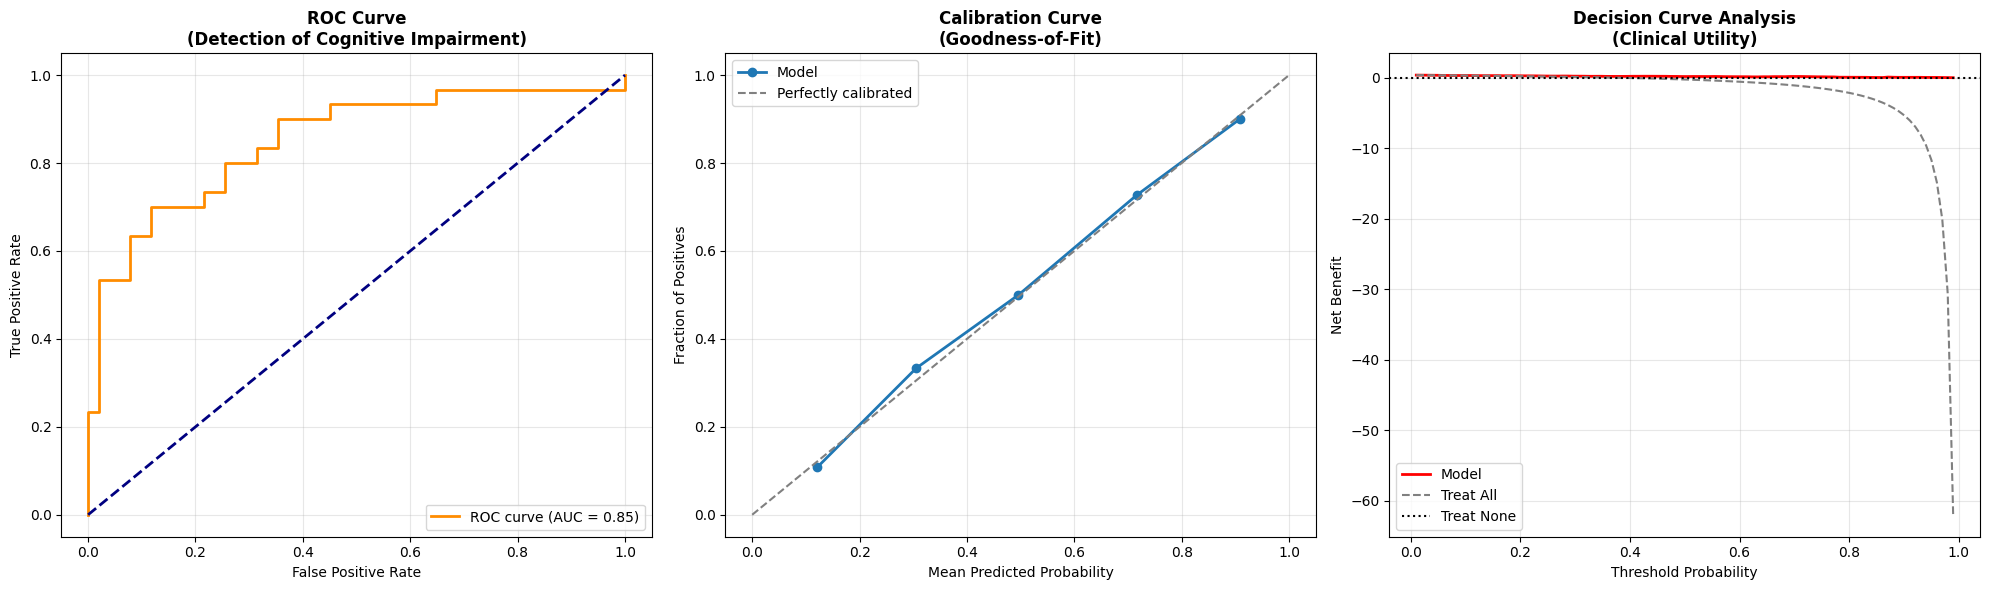

ROC AUC = 0.850


In [51]:

# ==========================================
# Clinical Utility & Performance Analysis
# ==========================================
# Evaluates ability to classify subjects as "Impaired" vs "Normal" (MoCA < 26).
# Uses LOOCV predictions from the best model for unbiased estimates.

from sklearn.metrics import roc_curve, auc
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression

print("\nGenerating Clinical Utility & Performance Plots...")

MOCA_CUTOFF = 26
y_binary    = (y.values < MOCA_CUTOFF).astype(int)
y_pred_cont = all_preds[best_name]   # LOOCV continuous predictions

print(f"Impairment Cutoff: < {MOCA_CUTOFF}")
print(f"Impaired subjects: {y_binary.sum()} / {len(y_binary)} ({y_binary.mean()*100:.1f}%)")

# Map continuous predictions → impairment probability via logistic regression
# (trained on the same LOOCV predictions — no additional leakage since predictions are OOF)
lr_mapper = LogisticRegression()
lr_mapper.fit(y_pred_cont.reshape(-1, 1), y_binary)
y_proba = lr_mapper.predict_proba(y_pred_cont.reshape(-1, 1))[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ROC Curve
fpr, tpr, _ = roc_curve(y_binary, y_proba)
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve\n(Detection of Cognitive Impairment)', fontweight='bold')
axes[0].legend(loc="lower right"); axes[0].grid(True, alpha=0.3)

# Calibration Curve
prob_true, prob_pred = calibration_curve(y_binary, y_proba, n_bins=5)
axes[1].plot(prob_pred, prob_true, marker='o', lw=2, label='Model')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Fraction of Positives')
axes[1].set_title('Calibration Curve\n(Goodness-of-Fit)', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Decision Curve Analysis
def net_benefit(y_true, y_prob, thresholds):
    nb = []
    for t in thresholds:
        yp = (y_prob >= t).astype(int)
        tp = np.sum((y_true == 1) & (yp == 1))
        fp = np.sum((y_true == 0) & (yp == 1))
        n  = len(y_true)
        nb.append((tp / n) - (fp / n) * (t / (1 - t)) if 0 < t < 1 else 0)
    return np.array(nb)

thresholds = np.linspace(0.01, 0.99, 100)
axes[2].plot(thresholds, net_benefit(y_binary, y_proba, thresholds), color='red', lw=2, label='Model')
axes[2].plot(thresholds, net_benefit(y_binary, np.ones_like(y_binary), thresholds),
             color='gray', linestyle='--', label='Treat All')
axes[2].axhline(0, color='black', linestyle=':', label='Treat None')
axes[2].set_xlabel('Threshold Probability'); axes[2].set_ylabel('Net Benefit')
axes[2].set_title('Decision Curve Analysis\n(Clinical Utility)', fontweight='bold')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('clinical_utility_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"ROC AUC = {roc_auc:.3f}")


In [52]:

# Final complete results — all models ranked by R²
print("\nFinal Results — Model B (Dance + Cognitive Only, No Augmentation, LOOCV n=81)")
print("="*72)
print(f"{'Model':<44} {'R²%':>7} {'MAE':>7} {'±3pt':>7}")
print("─"*72)
for name, m in sorted(all_metrics.items(), key=lambda x: x[1]['r2'], reverse=True):
    star = "★" if name == best_name else " "
    print(f"{star} {name:<43} {m['r2']*100:>6.1f}% {m['mae']:>7.2f} {m['a3']*100:>6.1f}%")



Final Results — Model B (Dance + Cognitive Only, No Augmentation, LOOCV n=81)
Model                                            R²%     MAE    ±3pt
────────────────────────────────────────────────────────────────────────
★ ★ NNLS Ensemble                               39.5%    2.48   72.8%
  Extra Trees [nested CV]                       38.7%    2.51   70.4%
  GPR Matern 3/2 [QT]                           33.6%    2.59   69.1%
  GBM      [nested CV]                          33.4%    2.66   66.7%
  RF       [nested CV]                          32.2%    2.71   61.7%
  SVR-RBF  [nested CV + QT]                     20.9%    2.89   65.4%
  Bayesian Ridge [QT]                           18.8%    3.05   54.3%
  Ridge-CV [QT]                                 18.7%    3.07   55.6%
  SVR-Poly [nested CV + QT]                     18.6%    2.76   66.7%


In [53]:

# Error analysis: distribution of LOOCV errors per subject
errors = y.values - all_preds[best_name]
print(f"Error analysis — {best_name}")
print(f"  Mean error   : {errors.mean():+.3f}")
print(f"  Std of errors: {errors.std():.3f}")
print(f"  Max overest  : {errors.min():.3f}")
print(f"  Max underest : {errors.max():.3f}")
print(f"  Within ±1    : {(np.abs(errors) <= 1).mean()*100:.1f}%")
print(f"  Within ±2    : {(np.abs(errors) <= 2).mean()*100:.1f}%")
print(f"  Within ±3    : {(np.abs(errors) <= 3).mean()*100:.1f}%")


Error analysis — ★ NNLS Ensemble
  Mean error   : -0.011
  Std of errors: 3.385
  Max overest  : -11.908
  Max underest : 4.832
  Within ±1    : 29.6%
  Within ±2    : 49.4%
  Within ±3    : 72.8%
